In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../notebooks/DATA/Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

<Axes: xlabel='Churn', ylabel='count'>

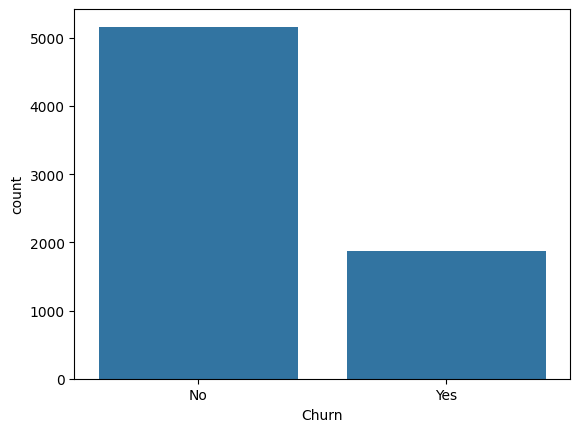

In [8]:
sns.countplot(data=df, x='Churn')

<Axes: xlabel='Churn', ylabel='TotalCharges'>

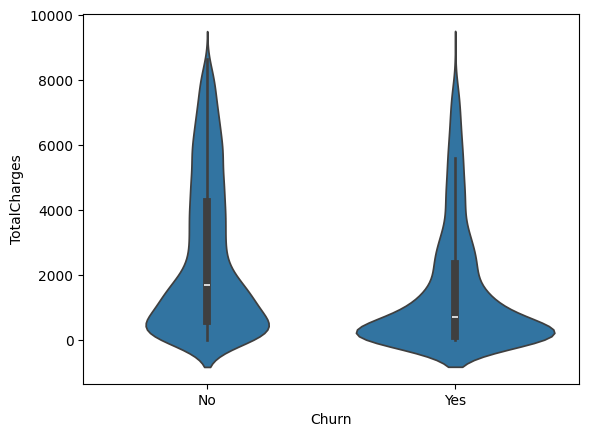

In [9]:
sns.violinplot(data=df, x='Churn', y='TotalCharges')

<Axes: xlabel='Contract', ylabel='TotalCharges'>

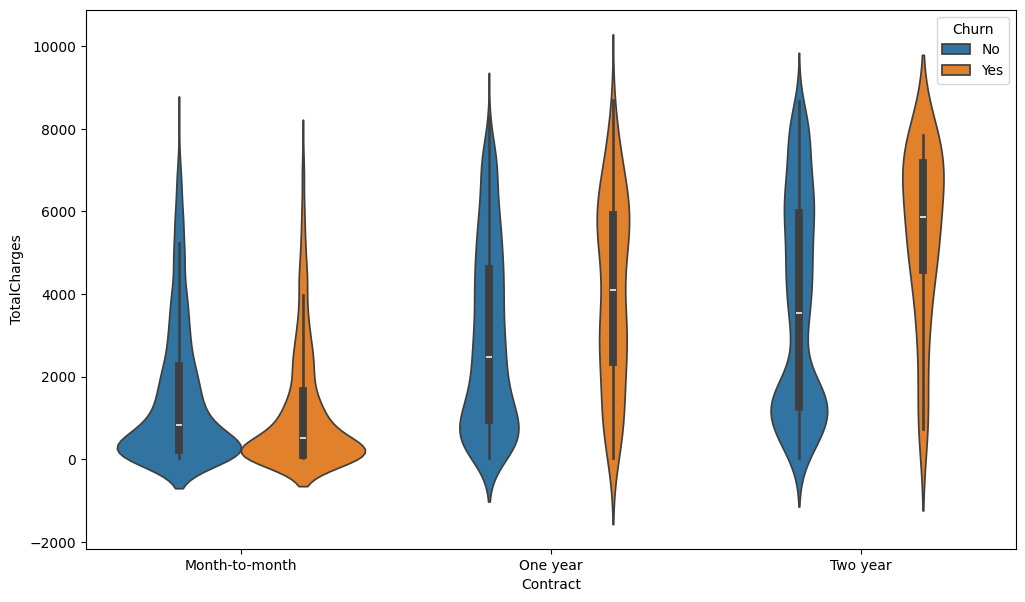

In [10]:
plt.figure(figsize=(12,7), dpi=100)
sns.violinplot(data=df, x='Contract', y='TotalCharges', hue='Churn')

In [11]:
def cohort(tenure):
    if tenure < 13:
        return '0-12 months'
    elif tenure < 25:
        return '12-24 months'
    elif tenure < 49:
        return '24-48 months'
    else:
        return '48+ months'

In [12]:
df['tenure_cohort'] = df['tenure'].apply(cohort)

In [13]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df['tenure_cohort'] = df['tenure'].apply(cohort)

In [14]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod',
            'tenure_cohort', 'Churn']

In [15]:
corr_df = pd.get_dummies(df[cat_cols])

In [16]:
corr_df['tenure'] = df['tenure']
corr_df['MonthlyCharges'] = df['MonthlyCharges']
corr_df['TotalCharges'] = df['TotalCharges']

In [17]:
corr_yes_churn = corr_df['Churn_Yes'].sort_values().iloc[1:-1]

In [18]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [19]:
df['tenure'].unique()

array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
       21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
        9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
       36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
       54, 51, 26, 39])

<Axes: xlabel='tenure', ylabel='Count'>

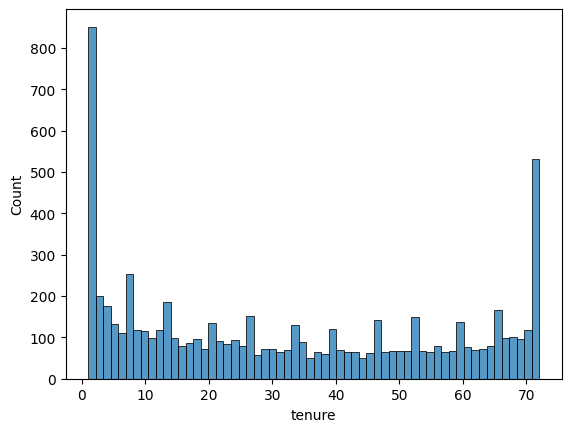

In [20]:
sns.histplot(data=df, x='tenure', bins=60)

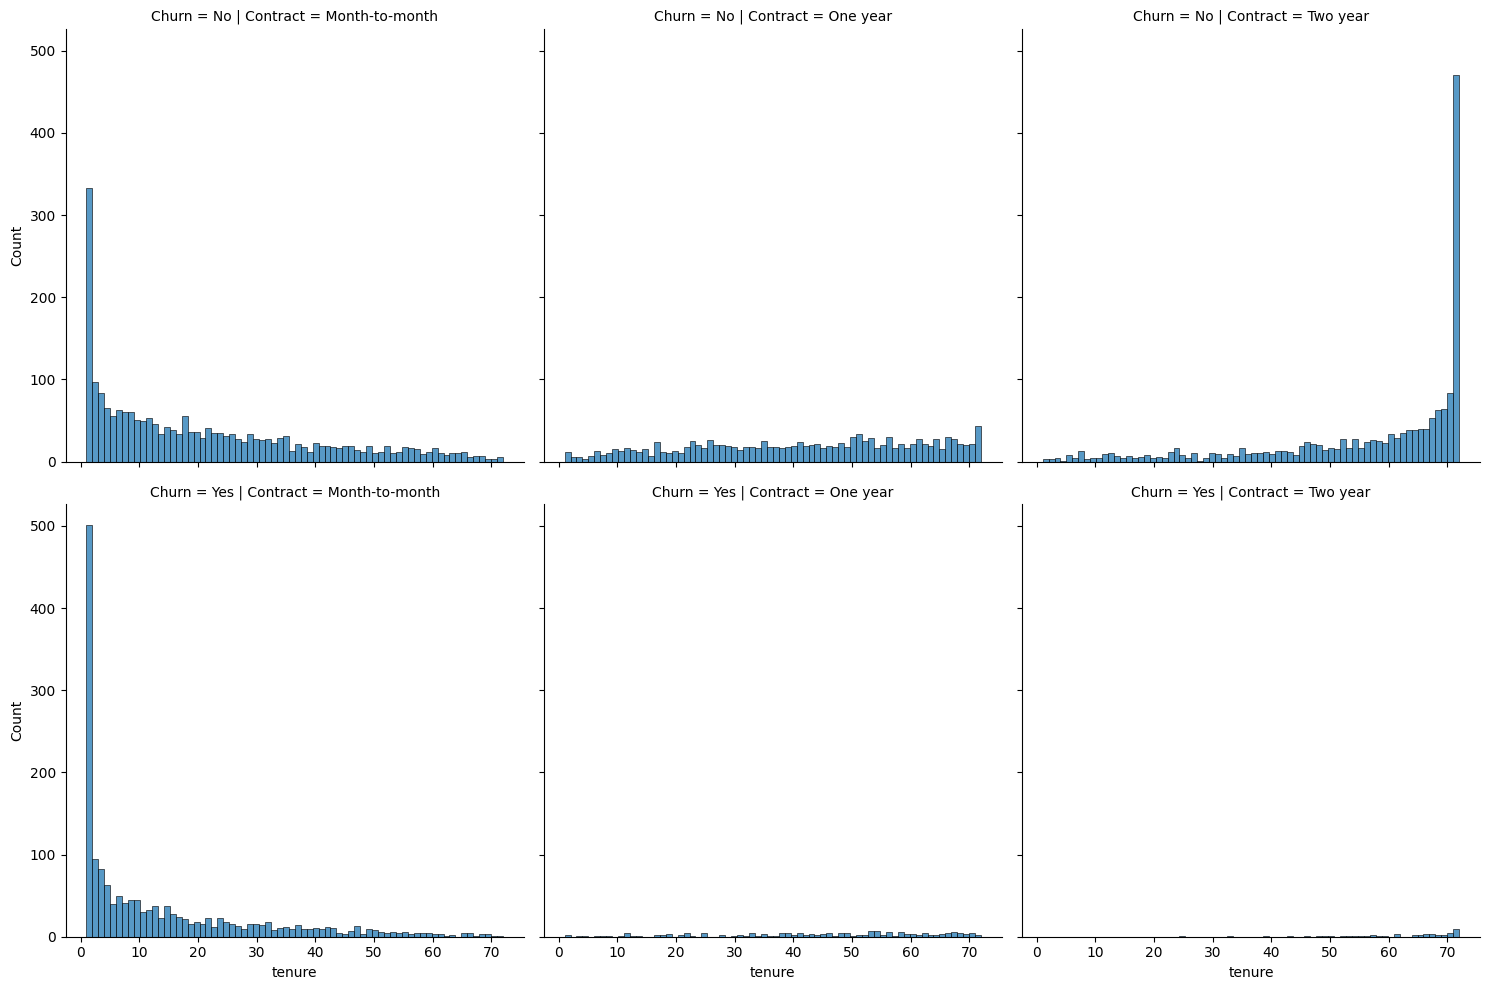

In [21]:
sns.displot(data=df, x='tenure', bins=70, col='Contract', row='Churn')


<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

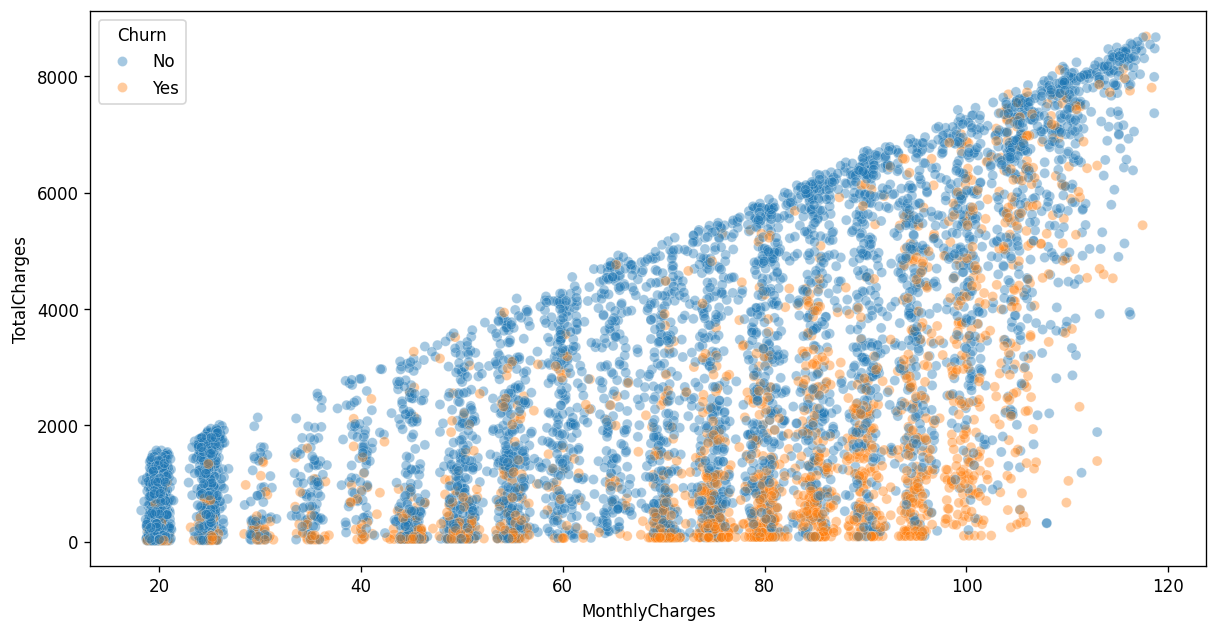

In [22]:
plt.figure(figsize=(12,6), dpi=120)
sns.scatterplot(data=df, x='MonthlyCharges', y='TotalCharges', hue='Churn', alpha=0.4, linewidth=0.3)

In [23]:
yes_churn = df.groupby(['Churn', 'tenure']).count().transpose()['Yes']

In [24]:
no_churn = df.groupby(['Churn', 'tenure']).count().transpose()['No']

In [25]:
no_churn

tenure,1,2,3,4,5,6,7,8,9,10,...,63,64,65,66,67,68,69,70,71,72
customerID,233,115,106,93,69,70,80,81,73,71,...,68,76,67,76,88,91,87,108,164,356
gender,233,115,106,93,69,70,80,81,73,71,...,68,76,67,76,88,91,87,108,164,356
SeniorCitizen,233,115,106,93,69,70,80,81,73,71,...,68,76,67,76,88,91,87,108,164,356
Partner,233,115,106,93,69,70,80,81,73,71,...,68,76,67,76,88,91,87,108,164,356
Dependents,233,115,106,93,69,70,80,81,73,71,...,68,76,67,76,88,91,87,108,164,356
PhoneService,233,115,106,93,69,70,80,81,73,71,...,68,76,67,76,88,91,87,108,164,356
MultipleLines,233,115,106,93,69,70,80,81,73,71,...,68,76,67,76,88,91,87,108,164,356
InternetService,233,115,106,93,69,70,80,81,73,71,...,68,76,67,76,88,91,87,108,164,356
OnlineSecurity,233,115,106,93,69,70,80,81,73,71,...,68,76,67,76,88,91,87,108,164,356
OnlineBackup,233,115,106,93,69,70,80,81,73,71,...,68,76,67,76,88,91,87,108,164,356


In [26]:
churn_rate = 100 * yes_churn / (no_churn + yes_churn)

<Axes: xlabel='tenure'>

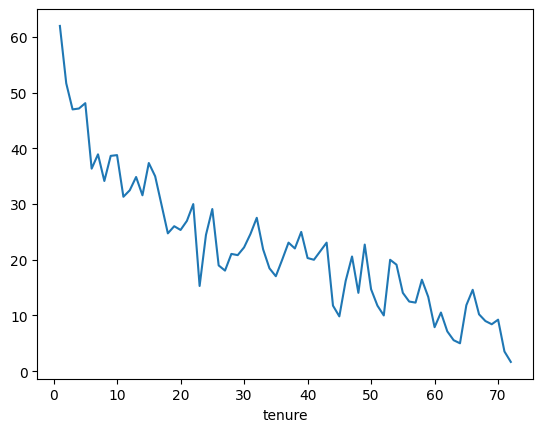

In [27]:
churn_rate.transpose()['customerID'].plot()

In [28]:
df[['tenure_cohort', 'tenure']]

,tenure_cohort,tenure
0,0-12 months,1
1,24-48 months,34
2,0-12 months,2
3,24-48 months,45
4,0-12 months,2
...,...,...
7027,12-24 months,24
7028,48+ months,72
7029,0-12 months,11
7030,0-12 months,4


<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

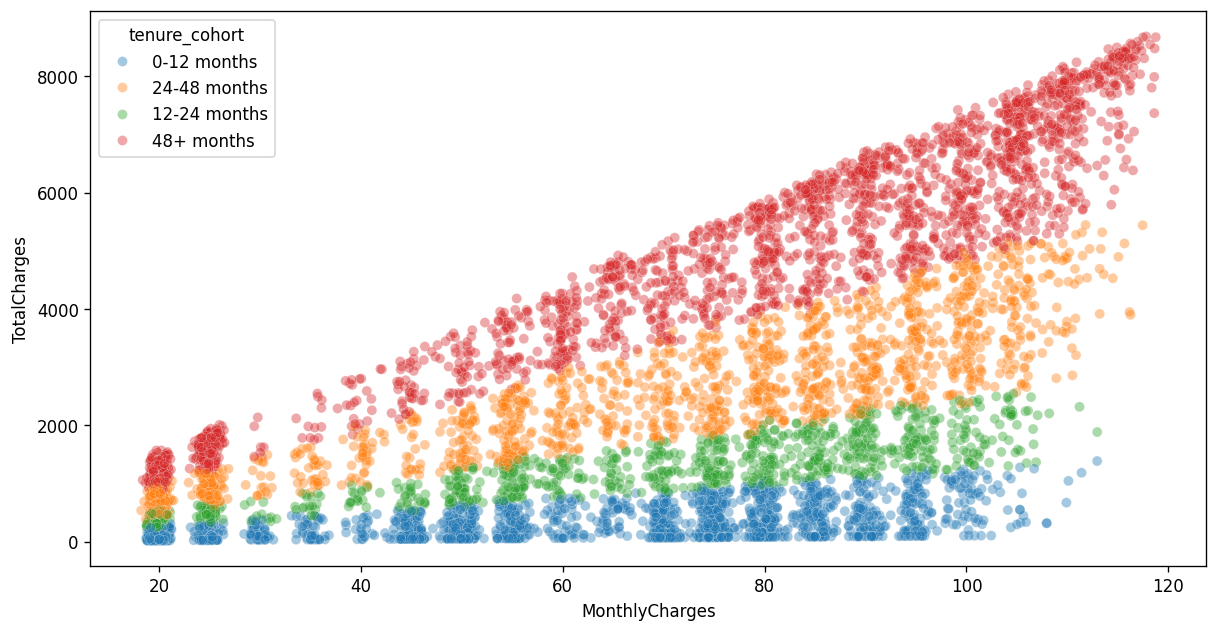

In [29]:
plt.figure(figsize=(12,6), dpi=120)
sns.scatterplot(data=df, x='MonthlyCharges', y='TotalCharges', hue='tenure_cohort', alpha=0.4, linewidth=0.3)

<Axes: xlabel='tenure_cohort', ylabel='count'>

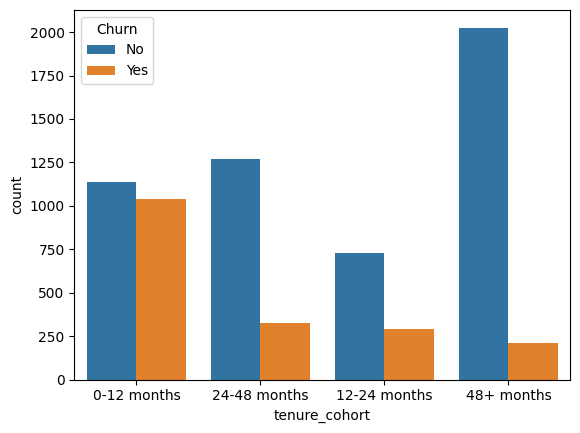

In [30]:
sns.countplot(data=df, x='tenure_cohort', hue='Churn')

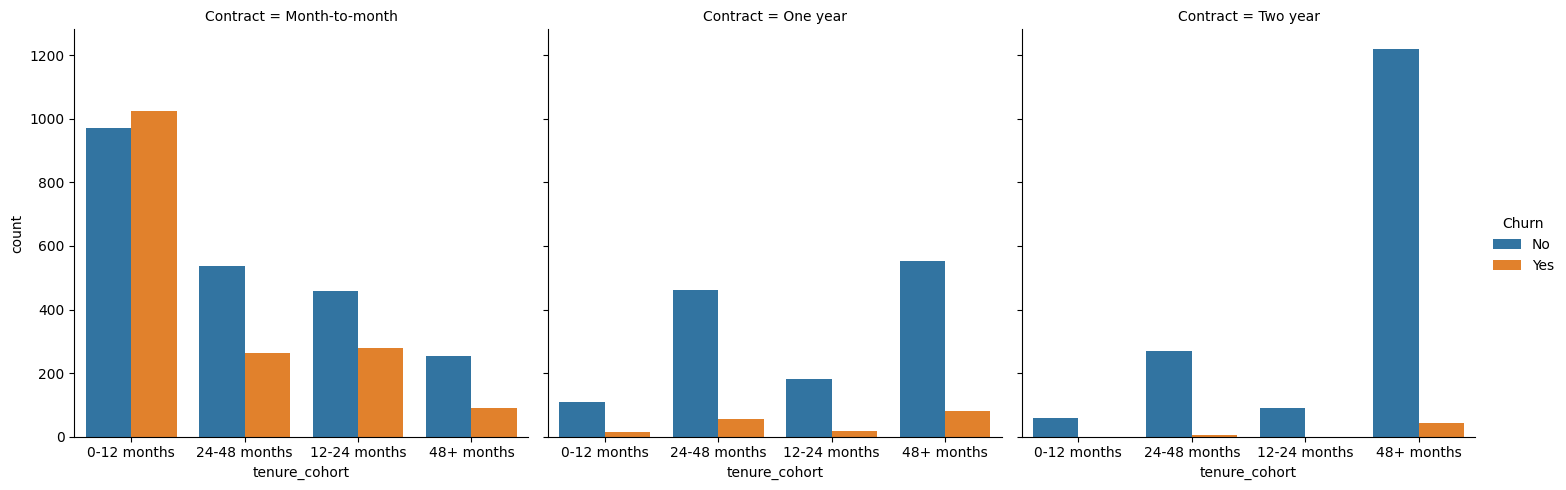

In [31]:
sns.catplot(data=df, x='tenure_cohort', hue='Churn', kind='count', col='Contract')

In [32]:
X = df.drop(['Churn', 'customerID'], axis=1)
y = df['Churn']

In [33]:
from sklearn.model_selection import train_test_split
import optuna

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [35]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

In [36]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [37]:
from sklearn.tree import DecisionTreeClassifier

In [38]:
dt = DecisionTreeClassifier()

In [39]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, make_scorer

f1_scorer = make_scorer(f1_score, pos_label='Yes')

def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 1, 10),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None, 0.33]),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
        "ccp_alpha": trial.suggest_float("ccp_alpha", 0.0, 0.05),
        "class_weight": 'balanced'
    }

    model = DecisionTreeClassifier(**params)

    score = cross_val_score(
        model, X_train, y_train,
        cv=5,
        scoring=f1_scorer
    ).mean()

    return score  

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=70)

print("Best params:", study.best_params)
    

[I 2026-03-17 18:45:30,126] A new study created in memory with name: no-name-b34ada41-0fbc-4c0a-85b8-cd37e4a22c0f
[I 2026-03-17 18:45:30,287] Trial 0 finished with value: 0.5547676038516351 and parameters: {'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 10, 'max_features': 0.33, 'criterion': 'gini', 'ccp_alpha': 0.020604719641850018}. Best is trial 0 with value: 0.5547676038516351.
[I 2026-03-17 18:45:30,529] Trial 1 finished with value: 0.5757876019294816 and parameters: {'max_depth': 8, 'min_samples_split': 15, 'min_samples_leaf': 3, 'max_features': None, 'criterion': 'gini', 'ccp_alpha': 0.02204177350543996}. Best is trial 1 with value: 0.5757876019294816.
[I 2026-03-17 18:45:30,664] Trial 2 finished with value: 0.5679491366370841 and parameters: {'max_depth': 4, 'min_samples_split': 5, 'min_samples_leaf': 7, 'max_features': 0.33, 'criterion': 'entropy', 'ccp_alpha': 0.02386397742336174}. Best is trial 1 with value: 0.5757876019294816.
[I 2026-03-17 18:45:30,906] Trial 

Best params: {'max_depth': 8, 'min_samples_split': 6, 'min_samples_leaf': 19, 'max_features': None, 'criterion': 'entropy', 'ccp_alpha': 0.011842627247657127}


In [40]:
best_params = study.best_params

final_tree_model = DecisionTreeClassifier(
    **best_params,
    random_state=42
)

In [41]:
final_tree_model.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,8
,min_samples_split,6
,min_samples_leaf,19
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [42]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

In [43]:
y_pred = final_tree_model.predict(X_test)

In [44]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.79      0.93      0.86       511
         Yes       0.66      0.35      0.46       193

    accuracy                           0.77       704
   macro avg       0.73      0.64      0.66       704
weighted avg       0.76      0.77      0.75       704



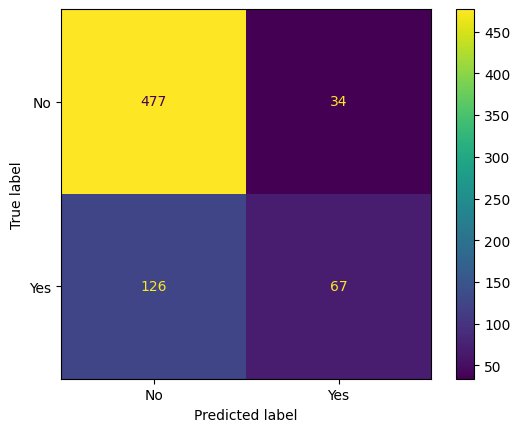

In [45]:
ConfusionMatrixDisplay.from_estimator(final_tree_model, X_test, y_test)

In [48]:
from sklearn.tree import plot_tree

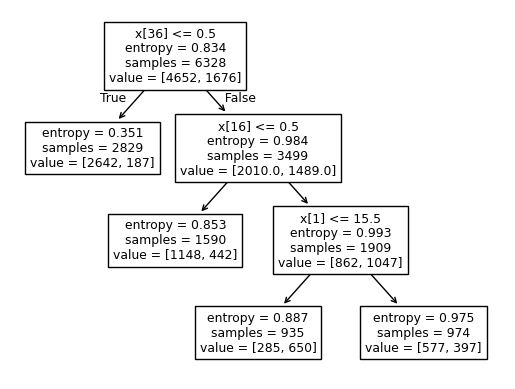

In [49]:
plot_tree(final_tree_model);

In [50]:
from sklearn.ensemble import RandomForestClassifier

In [51]:
f1_scorer = make_scorer(f1_score, pos_label='Yes')

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "class_weight": "balanced",
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestClassifier(**params)

    score = cross_val_score(
        model, X_train, y_train,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
        
    ).mean()

    return -score  

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)

print("Best params:", study.best_params)
    

[I 2026-03-17 18:46:24,588] A new study created in memory with name: no-name-6d149d6f-ab36-4e41-8005-09bf0132e46e
[I 2026-03-17 18:46:31,319] Trial 0 finished with value: -0.7324606460233908 and parameters: {'n_estimators': 326, 'max_depth': 3, 'min_samples_split': 16, 'min_samples_leaf': 17, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: -0.7324606460233908.
[I 2026-03-17 18:46:36,464] Trial 1 finished with value: -0.7677028267425958 and parameters: {'n_estimators': 107, 'max_depth': 7, 'min_samples_split': 19, 'min_samples_leaf': 3, 'max_features': 0.5, 'bootstrap': True}. Best is trial 1 with value: -0.7677028267425958.
[I 2026-03-17 18:46:43,612] Trial 2 finished with value: -0.7665948585379865 and parameters: {'n_estimators': 330, 'max_depth': 12, 'min_samples_split': 13, 'min_samples_leaf': 4, 'max_features': 0.5, 'bootstrap': False}. Best is trial 1 with value: -0.7677028267425958.
[I 2026-03-17 18:46:47,503] Trial 3 finished with value: -0.764227313314

Best params: {'n_estimators': 499, 'max_depth': 18, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.3, 'bootstrap': True}


In [52]:
best_params = study.best_params

final_rfc_model = RandomForestClassifier(
    **best_params,
    random_state=42
)

In [53]:
final_rfc_model.fit(X_train, y_train)

,n_estimators,499
,criterion,'gini'
,max_depth,18
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.3
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [54]:
y_pred = final_rfc_model.predict(X_test)

In [55]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.83      0.91      0.86       511
         Yes       0.67      0.49      0.57       193

    accuracy                           0.79       704
   macro avg       0.75      0.70      0.72       704
weighted avg       0.78      0.79      0.78       704



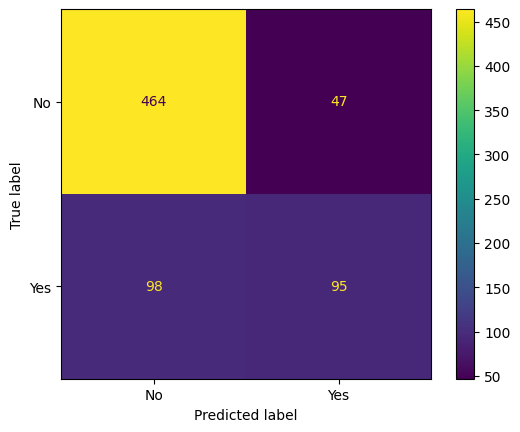

In [56]:
ConfusionMatrixDisplay.from_estimator(final_rfc_model, X_test, y_test)

In [57]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

In [61]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [62]:
f1_scorer = make_scorer(f1_score, pos_label=1, average='binary')

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 1),
        "reg_lambda": trial.suggest_float("reg_lambda", 1, 10),
        "n_jobs": -1
    }

    model = XGBClassifier(**params)

    score = cross_val_score(
        model, X_train, y_train_enc,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    ).mean()

    return score  

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

print("Best params:", study.best_params)
    

[I 2026-03-17 18:58:23,646] A new study created in memory with name: no-name-b71ec0d6-9c4d-45f9-8eed-37a30108b1ea
[I 2026-03-17 18:58:27,835] Trial 0 finished with value: 0.789824101305659 and parameters: {'n_estimators': 652, 'max_depth': 8, 'learning_rate': 0.042622200786351205, 'subsample': 0.9011392012889052, 'colsample_bytree': 0.8275281858438659, 'reg_alpha': 0.6784017772313663, 'reg_lambda': 9.922806644310912}. Best is trial 0 with value: 0.789824101305659.
[I 2026-03-17 18:58:28,910] Trial 1 finished with value: 0.7988322125021072 and parameters: {'n_estimators': 418, 'max_depth': 4, 'learning_rate': 0.10608771483558765, 'subsample': 0.9997480797692752, 'colsample_bytree': 0.8648847258817982, 'reg_alpha': 0.6951631201171562, 'reg_lambda': 4.028221031398236}. Best is trial 1 with value: 0.7988322125021072.
[I 2026-03-17 18:58:32,241] Trial 2 finished with value: 0.7812909228281162 and parameters: {'n_estimators': 743, 'max_depth': 6, 'learning_rate': 0.0866332494699931, 'subsamp

Best params: {'n_estimators': 513, 'max_depth': 3, 'learning_rate': 0.0176978276956596, 'subsample': 0.7547404143600678, 'colsample_bytree': 0.7036229935023489, 'reg_alpha': 0.04574898638248104, 'reg_lambda': 9.111824859371906}


In [63]:
best_params = study.best_params

final_xgb_model = XGBClassifier(
    **best_params,
    random_state=42
)

In [64]:
final_xgb_model.fit(X_train, y_train_encoded)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7036229935023489
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [65]:
y_pred = final_xgb_model.predict(X_test)

In [66]:
print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86       511
           1       0.67      0.47      0.55       193

    accuracy                           0.79       704
   macro avg       0.75      0.69      0.71       704
weighted avg       0.78      0.79      0.78       704



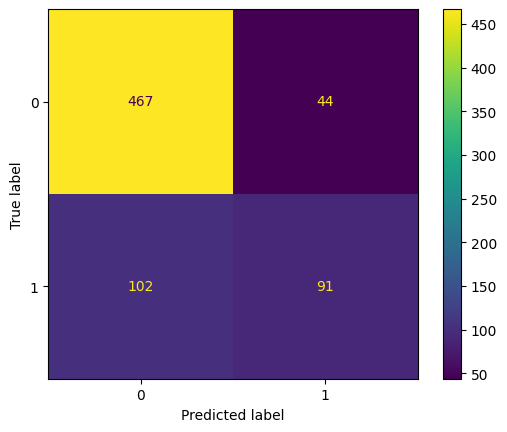

In [67]:
ConfusionMatrixDisplay.from_estimator(final_xgb_model, X_test, y_test_encoded)

In [70]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

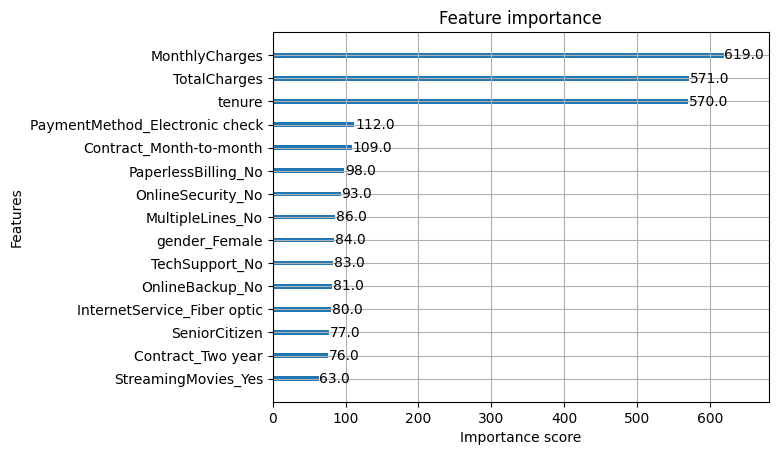

In [72]:
plot_importance(final_xgb_model, max_num_features=15)
plt.show()

In [74]:
y_prob = final_xgb_model.predict_proba(X_test)[:, 1]

for threshold in [0.5, 0.45, 0.4, 0.35, 0.3]:
    y_pred_custom = (y_prob >= threshold).astype(int)
    print(f"\nПорог: {threshold}")
    print(classification_report(y_test_enc, y_pred_custom, 
                                target_names=["No", "Yes"], 
                                zero_division=0))


Порог: 0.5
              precision    recall  f1-score   support

          No       0.82      0.91      0.86       511
         Yes       0.67      0.47      0.55       193

    accuracy                           0.79       704
   macro avg       0.75      0.69      0.71       704
weighted avg       0.78      0.79      0.78       704


Порог: 0.45
              precision    recall  f1-score   support

          No       0.84      0.89      0.87       511
         Yes       0.66      0.55      0.60       193

    accuracy                           0.80       704
   macro avg       0.75      0.72      0.74       704
weighted avg       0.79      0.80      0.80       704


Порог: 0.4
              precision    recall  f1-score   support

          No       0.86      0.84      0.85       511
         Yes       0.61      0.64      0.62       193

    accuracy                           0.79       704
   macro avg       0.73      0.74      0.74       704
weighted avg       0.79      0.79    

In [75]:
y_prob = final_xgb_model.predict_proba(X_test)[:, 1]
y_pred_final = (y_prob >= 0.4).astype(int)

print(classification_report(y_test_enc, y_pred_final,
                            target_names=["No", "Yes"],
                            zero_division=0))

              precision    recall  f1-score   support

          No       0.86      0.84      0.85       511
         Yes       0.61      0.64      0.62       193

    accuracy                           0.79       704
   macro avg       0.73      0.74      0.74       704
weighted avg       0.79      0.79      0.79       704

